# Sports Analytics: Clustering and Association Rule Analysis

In [1]:
# Importing Libraries
import sys
!{sys.executable} -m pip install mlxtend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import rand_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings("ignore")

In [9]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/fb-data_2020-21_players_share.csv")

df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,player,short_name,country,position,club,league,age,birth,matches,starts,...,carry_final_3rd,carry_box,miscontrol,disposs,pass_on_target,pass_rcv,prog_pass_rcv,team_abbr,primary_color,secondary_color
0,Aaron Connolly,A. Connolly,Republic of Ireland,FW,Brighton,Premier League,21,2000,17,9,...,8,4,29,15,357,143,66,BHA,#FFFFFF,#0057B8
1,Aaron Cresswell,A. Cresswell,England,DF,West Ham,Premier League,32,1989,36,36,...,40,3,7,9,1366,1316,30,WHU,#7A263A,#1bb1e7
2,Aarón Escandell,A. Escandell,Spain,GK,Granada,La Liga,26,1995,5,5,...,0,0,0,0,54,54,0,GRA,#FFFFFF,#1C61AB
3,Aaron Hickey,A. Hickey,Scotland,DF,Bologna,Serie A,19,2002,11,10,...,18,2,10,13,301,280,16,BOL,#243D5F,#C7253A
4,Aaron Leya Iseka,A. Leya Iseka,Belgium,FW,Metz,Ligue 1,24,1997,21,12,...,12,10,32,20,543,252,62,MTZ,#FFFFFF,#892435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,Zaydou Youssouf,Z. Youssouf,France,MF,Saint-Étienne,Ligue 1,22,1999,29,14,...,4,1,16,31,523,463,24,ASSE,#FFFFFF,#0BC300
2819,Zeki Çelik,Z. Çelik,Turkey,DF,Lille,Ligue 1,24,1997,29,28,...,36,12,24,20,1298,1214,66,LOSC,#1e1c2c,#EA0900
2820,Zinedine Ferhat,Z. Ferhat,Algeria,MF,Nîmes,Ligue 1,28,1993,33,33,...,49,30,69,68,1731,1260,202,NIM,#FFFFFF,#E31F2B
2821,Zinédine Ould Khaled,Z.O. Khaled,France,MF,Angers,Ligue 1,21,2000,3,0,...,2,0,0,0,20,18,1,ANG,#201600,#FFFFFF


In [10]:
# Filtering Out Non Premier League Players
df = df[df["league"] == "Premier League"]

In [11]:
# Checking Column Names
list(df.columns)

['player',
 'short_name',
 'country',
 'position',
 'club',
 'league',
 'age',
 'birth',
 'matches',
 'starts',
 'mins',
 'nineties',
 'assists_p_90',
 'npG_p_90',
 'npGA_p_90',
 'xA_p_90',
 'npxG_p_90',
 'npxGA_p_90',
 'shots_p_90',
 'shots_on_target_p_90',
 'shot_on_target_pct',
 'goals_p_shot',
 'goals_p_shot_on_target',
 'avg_shot_dist',
 'fk_s_p_90',
 'npxG_p_shot',
 'npxG_difference',
 'pass_cmp_p_90',
 'pass_attempted_p_90',
 'pass_cmp_pct',
 'total_dist_pass_p_90',
 'prog_dist_pass_p_90',
 'short_cmp_p_90',
 'short_attempted_p_90',
 'short_cmp_pct',
 'med_cmp_p_90',
 'med_attempted_p_90',
 'med_cmp_pct',
 'long_cmp_p_90',
 'long_attempted_p_90',
 'long_cmp_pct',
 'key_pass_p_90',
 'pass_final_3rd_p_90',
 'pass_box_p_90',
 'cross_box_p_90',
 'prog_pass_p_90',
 'live_pass_attempted_p_90',
 'dead_pass_attempted_p_90',
 'fk_pass_attempted_p_90',
 'through_ball_cmp_p_90',
 'pass_under_pressure_p_90',
 'switches_p_90',
 'crosses_p_90',
 'ground_pass_p_90',
 'low_pass_p_90',
 'high_pa

In [12]:
# Choosing Defensive Variables
df_1 = df[['player',
         'tackle_attempted_p_90',
         'tackle_won_p_90',
         'intercepts_p_90',
         'clearances_p_90',
         'blocks_p_90']]

df_1

,player,tackle_attempted_p_90,tackle_won_p_90,intercepts_p_90,clearances_p_90,blocks_p_90
0,Aaron Connolly,0.80,0.57,0.00,0.11,1.02
1,Aaron Cresswell,0.88,0.37,1.02,2.81,1.36
7,Aaron Ramsdale,0.00,0.00,0.00,0.03,0.00
9,Aaron Wan-Bissaka,2.85,1.53,1.94,3.18,3.32
15,Abdoulaye Doucouré,2.07,1.55,1.29,1.07,1.59
...,...,...,...,...,...,...
2770,Yan Valery,2.73,1.82,2.73,4.55,4.55
2791,Yerry Mina,1.16,0.56,0.60,6.05,1.77
2799,Youri Tielemans,2.06,1.50,0.97,0.78,1.53
2816,Yves Bissouma,3.29,2.14,1.73,1.94,1.62


In [14]:
# Loading Original Dataset
original_df = pd.read_csv("/content/drive/MyDrive/EPL_20_21.csv")

# Renaming Name column
original_df= original_df.rename(columns={'Name' : 'player'})

In [15]:
# Merging Both Datasets
merged_df = df_1.merge(original_df, on="player", how="left")
merged_df

,player,tackle_attempted_p_90,tackle_won_p_90,intercepts_p_90,clearances_p_90,blocks_p_90,Club,Nationality,Position,Age,...,Goals,Assists,Passes_Attempted,Perc_Passes_Completed,Penalty_Goals,Penalty_Attempted,xG,xA,Yellow_Cards,Red_Cards
0,Aaron Connolly,0.80,0.57,0.00,0.11,1.02,Brighton,IRL,FW,20.0,...,2.0,1.0,101.0,78.2,0.0,0.0,0.40,0.02,0.0,0.0
1,Aaron Cresswell,0.88,0.37,1.02,2.81,1.36,West Ham United,ENG,DF,30.0,...,0.0,8.0,2060.0,74.8,0.0,0.0,0.03,0.17,3.0,0.0
2,Aaron Ramsdale,0.00,0.00,0.00,0.03,0.00,Sheffield United,ENG,GK,22.0,...,0.0,0.0,1141.0,49.1,0.0,0.0,0.00,0.00,1.0,0.0
3,Aaron Wan-Bissaka,2.85,1.53,1.94,3.18,3.32,Manchester United,ENG,DF,22.0,...,2.0,4.0,2065.0,86.0,0.0,0.0,0.03,0.07,3.0,0.0
4,Abdoulaye Doucouré,2.07,1.55,1.29,1.07,1.59,Everton,FRA,MF,27.0,...,2.0,3.0,1332.0,86.0,0.0,0.0,0.08,0.08,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,Yan Valery,2.73,1.82,2.73,4.55,4.55,Southampton,FRA,"DF,MF",21.0,...,0.0,0.0,64.0,82.8,0.0,0.0,0.27,0.00,0.0,0.0
544,Yerry Mina,1.16,0.56,0.60,6.05,1.77,Everton,COL,DF,25.0,...,2.0,0.0,1227.0,90.9,0.0,0.0,0.06,0.00,2.0,0.0
545,Youri Tielemans,2.06,1.50,0.97,0.78,1.53,Leicester City,BEL,MF,23.0,...,6.0,4.0,2559.0,78.6,2.0,2.0,0.12,0.09,6.0,0.0
546,Yves Bissouma,3.29,2.14,1.73,1.94,1.62,Brighton,MLI,MF,23.0,...,1.0,0.0,1676.0,87.2,0.0,0.0,0.04,0.03,8.0,1.0



# Data Cleaning

In [16]:
# Dropping Columns
df_final = merged_df.drop(["player", "Club", "Nationality", "Position", "Age", "Perc_Passes_Completed", "Yellow_Cards", "Red_Cards"], axis=1)

In [17]:
# Renaming Columns
df_final = df_final.rename(columns={
    "Passes_Attempted": "Passes Attempted",
    "tackle_attempted_p_90": "Tackles attempted",
    "tackle_won_p_90": "Tackles Won",
    "intercepts_p_90": "Intercepts",
    "clearances_p_90": "Clearences",
    "blocks_p_90": "Blocks",
    "Penalty_Goals": "Penalty Goals",
    "Penalty_Attempted": "Penalty Attempted",
    "Yellow_Cards": "Yellow Cards",
    "Red_Cards": "Red Cards"})

In [18]:
# Checking For Missing Values
df_final.isnull().sum()

,0
Tackles attempted,0
Tackles Won,0
Intercepts,0
Clearences,0
Blocks,0
Matches,9
Starts,9
Mins,9
Goals,9
Assists,9


In [19]:
# Dropping Columns With Missing Values
cleaned_df = df_final.dropna()
cleaned_df.shape

(539, 15)

In [20]:
# Checking missing values have been removed
cleaned_df.isnull().sum()

,0
Tackles attempted,0
Tackles Won,0
Intercepts,0
Clearences,0
Blocks,0
Matches,0
Starts,0
Mins,0
Goals,0
Assists,0


# Principal Component Analysis

In [21]:
# Scaling the Data
scaler=StandardScaler(with_mean=True, with_std=True)
scaled_data= pd.DataFrame(scaler.fit_transform(cleaned_df),columns=cleaned_df.columns)

In [22]:
# Performing PCA On New Dataset
pca_dataset = PCA()
pca_dataset.fit(scaled_data)
results = pca_dataset.transform(scaled_data)

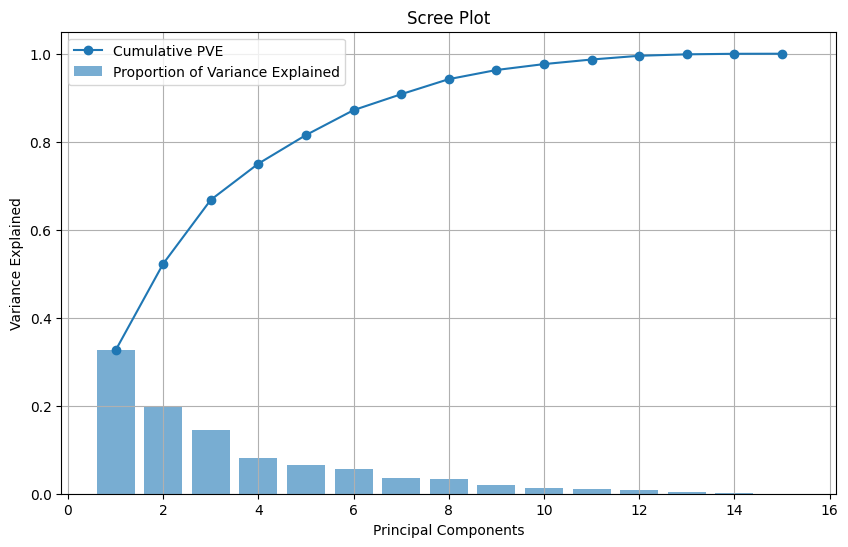

In [23]:
# Creating a Scree Plot
pve = pca_dataset.explained_variance_ratio_
cumulative_pve = np.cumsum(pve)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pve) + 1), pve, alpha=0.6, label="Proportion of Variance Explained")
plt.plot(range(1, len(pve) + 1), cumulative_pve, marker="o", label="Cumulative PVE")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")
plt.legend()
plt.grid()
plt.show()

In [24]:
# Creating Dataframes with PC Loadings
pca = PCA(n_components=3)
results = pca.fit_transform(scaled_data)
pca_df_1 = pd.DataFrame(pca.fit_transform(scaled_data), columns=["PC1", "PC2","PC3"])
pca_df = pd.DataFrame(pca.components_.T, index=scaled_data.columns, columns=["PC1", "PC2", "PC3"])
pca_df

,PC1,PC2,PC3
Tackles attempted,-0.042601,0.306800,0.479856
Tackles Won,-0.032773,0.284441,0.468190
Intercepts,0.050439,0.307124,0.165504
Clearences,-0.029037,0.356181,0.052075
Blocks,-0.036469,0.278426,0.339068
Matches,0.389105,0.186641,-0.163741
Starts,0.381851,0.231635,-0.203926
Mins,0.382781,0.231702,-0.204692
Goals,0.330632,-0.231905,0.152851
Assists,0.342376,-0.102712,0.114108


In [25]:
pca_df_1

,PC1,PC2,PC3
0,-0.656487,-2.013758,-0.167018
1,3.514040,1.526199,-1.525353
2,1.600983,0.486919,-3.300866
3,2.587907,3.189062,0.088573
4,1.640694,1.305529,-0.308028
...,...,...,...
534,-2.311612,1.208486,2.704904
535,0.296417,1.411651,-1.037270
536,4.995328,0.730272,0.381149
537,1.696416,2.944921,-0.341300


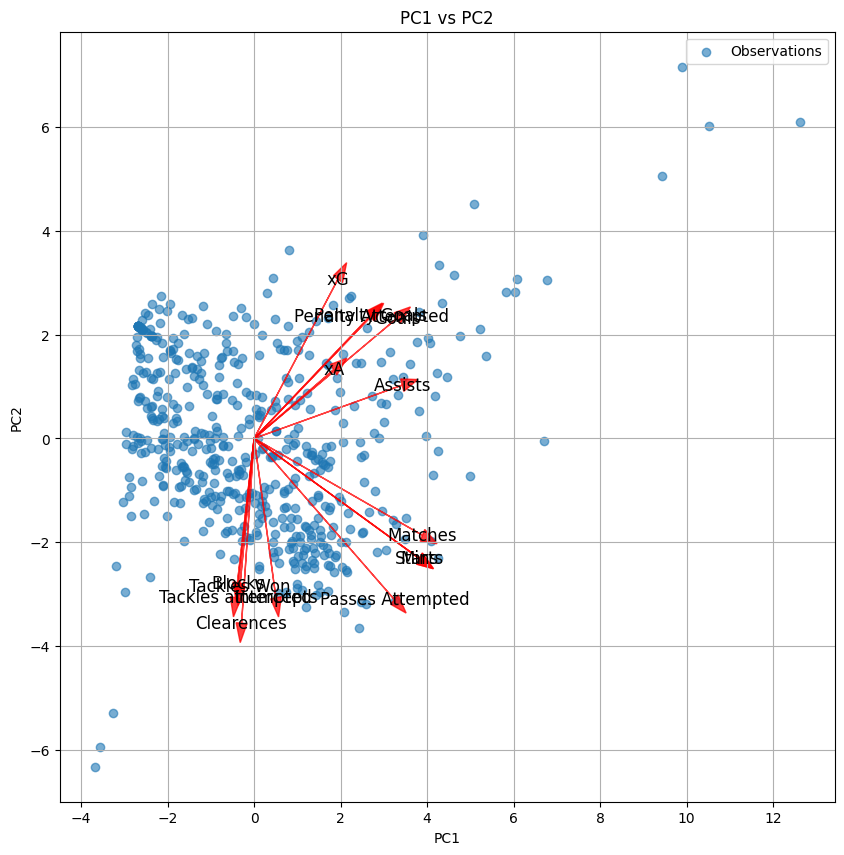

In [26]:
# PC1 vs PC2 Biplot
results = pca_dataset.transform(scaled_data)
results[:, 1] *= -1
loadings = pca.components_.T
loadings[:, 1] *= -1
i, j = 0, 1
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(results[:, i], results[:, j], alpha=0.6, label='Observations')


# Plotting arrows
for k in range(pca.components_.shape[1]):
  ax.arrow(0, 0, pca.components_[i, k] * 10, pca.components_[j, k] * 10,
             color='r', alpha=0.75, head_width=0.25)
  ax.text(pca.components_[i, k] * 10, pca.components_[j, k] * 10,
            scaled_data.columns[k], color='black', fontsize=12, ha='center', va='center')


ax.set_xlabel(f'PC{i+1}')
ax.set_ylabel(f'PC{j+1}')
ax.set_title('PC1 vs PC2')
ax.grid()
ax.legend()
plt.savefig('Biplot_PC1_PC2.png')
plt.show()

# K-means Clustering

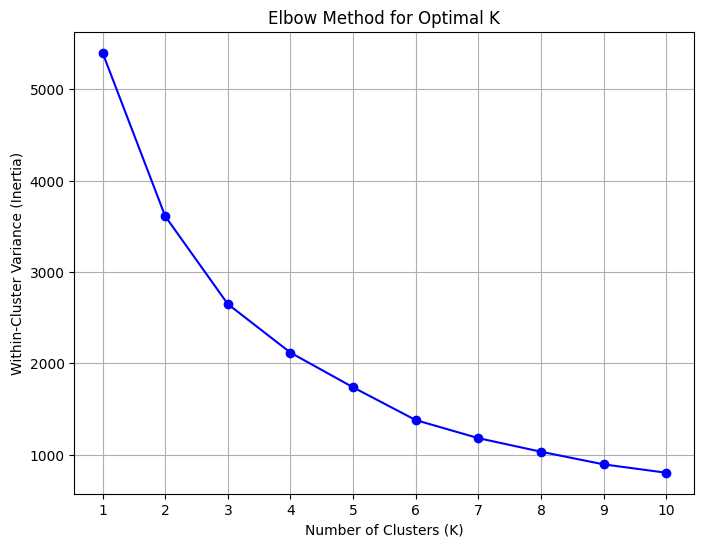

In [27]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=38,
        n_init=20
    ).fit(pca_df_1)
    inertia.append(kmeans.inertia_)


# Plotting the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o', linestyle='-', color='blue')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Variance (Inertia)")
plt.xticks(k_values)
plt.grid()
plt.savefig('Elbow Curve')
plt.show()

In [28]:
pca_df_1["PC2"] *= -1
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
).fit(pca_df_1[['PC1', 'PC2', 'PC3']])

# Extract cluster labels
cluster_labels = kmeans.labels_
pca_df_1["Cluster"] = cluster_labels

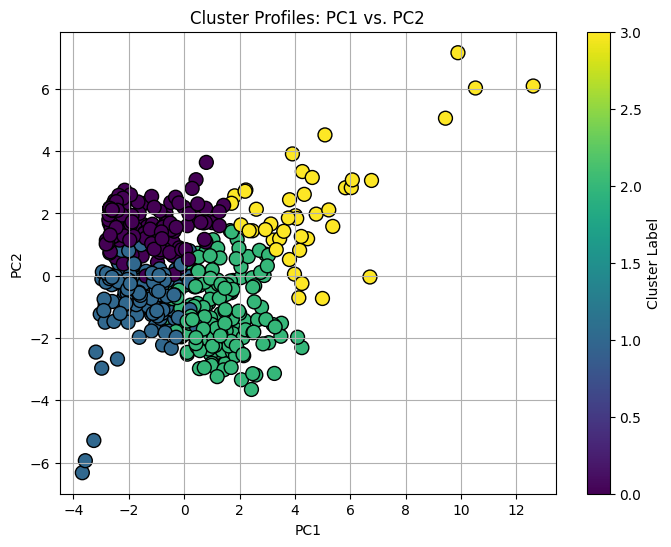

In [29]:
# Clusters for PC1 vs PC2
plt.figure(figsize=(8, 6))
plt.scatter(pca_df_1["PC1"], pca_df_1["PC2"], c=cluster_labels, cmap="viridis", s=100, edgecolor='k')
plt.title(f"Cluster Profiles: {"PC1"} vs. {"PC2"}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster Label")
plt.grid()
plt.savefig('K means clustering.png')
plt.show()

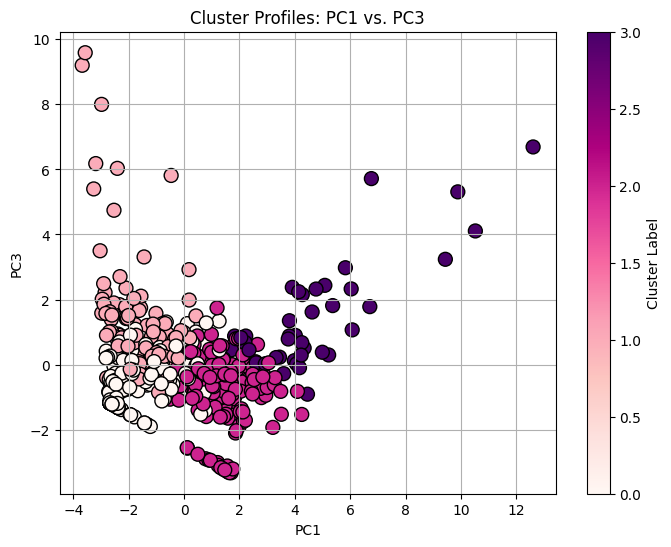

In [30]:
# Clusters for PC1 vs PC3
plt.figure(figsize=(8, 6))
plt.scatter(pca_df_1["PC1"], pca_df_1["PC3"], c=cluster_labels, cmap="RdPu", s=100, edgecolor='k')
plt.title(f"Cluster Profiles: {"PC1"} vs. {"PC3"}")
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid()
plt.show()

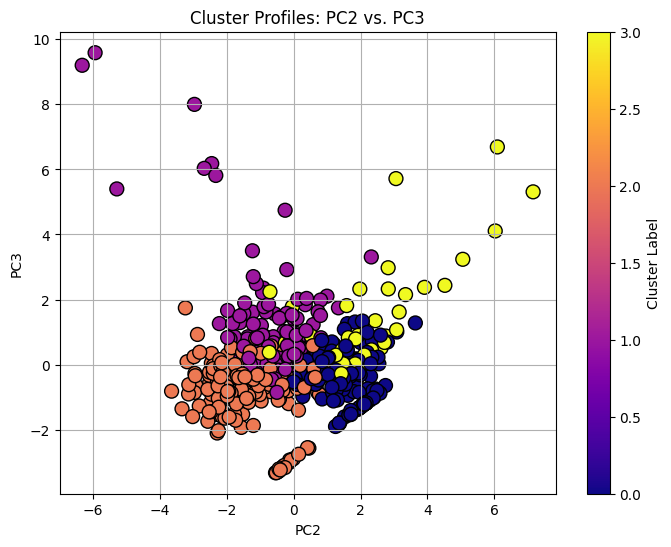

In [31]:
# Clusters for PC2 vs PC3
plt.figure(figsize=(8, 6))
plt.scatter(pca_df_1["PC2"], pca_df_1["PC3"], c=cluster_labels, cmap="plasma", s=100, edgecolor='k')
plt.title(f"Cluster Profiles: {"PC2"} vs. {"PC3"}")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid()
plt.show()

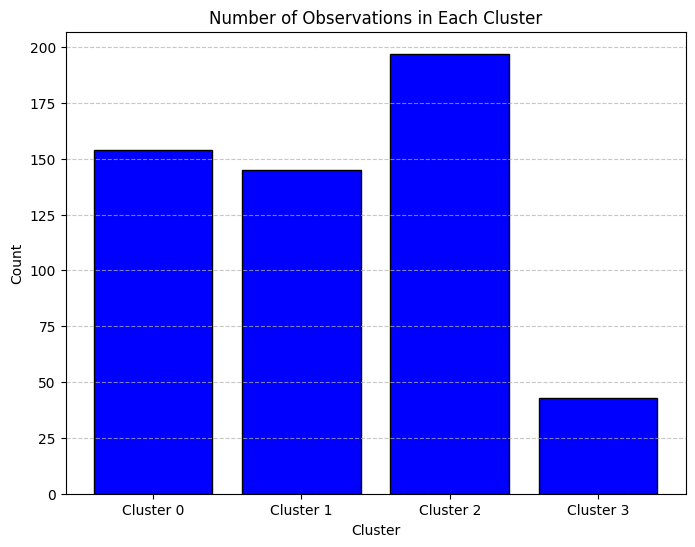

In [32]:
# Checking N.O of Observations in Each Cluster
cluster_counts = pca_df_1["Cluster"].value_counts().sort_index()
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts.index, cluster_counts.values, color="blue", edgecolor="black")
plt.title("Number of Observations in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(ticks=cluster_counts.index, labels=[f"Cluster {i}" for i in cluster_counts.index])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Hierarchical Clustering

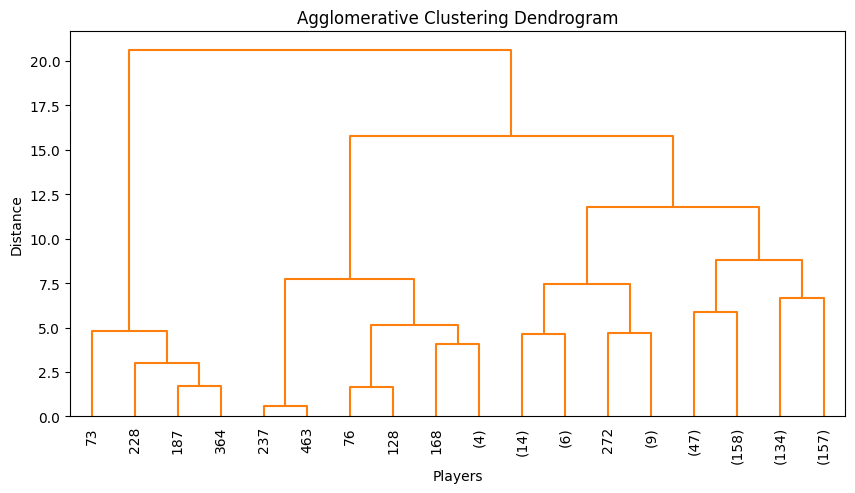

In [33]:
hc_data = pca_df_1[["PC1", "PC2", "PC3"]]
hc = AgglomerativeClustering(n_clusters=4, linkage='complete')
hc_labels = hc.fit_predict(hc_data)

#Computing Linkage Matrix for Dendrogram
linkage_matrix = linkage(hc_data, method='complete')

# Plotting a Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels= None, truncate_mode='level', p=4, leaf_rotation=90, leaf_font_size=10, color_threshold=np.inf)
plt.title("Agglomerative Clustering Dendrogram")
plt.xlabel("Players")
plt.ylabel("Distance")
plt.savefig('Hierarchical clustering.png')
plt.show()

In [34]:
# Calculating Rand Indexes
ri = rand_score(cluster_labels, hc_labels)
ari = adjusted_rand_score(cluster_labels, hc_labels)
print(f"Rand Index: {ri:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")

Rand Index: 0.4199
Adjusted Rand Index: 0.1008


# Association Rule Analysis

In [35]:
# Choosing Columns for Analysis
cleaned_df['High Goals'] = (cleaned_df['Goals'] > cleaned_df['Goals'].median())
cleaned_df['High Assists'] = (cleaned_df['Assists'] > cleaned_df['Assists'].median())
cleaned_df['High Tackles'] = (cleaned_df['Tackles attempted'] > cleaned_df['Tackles attempted'].median())
cleaned_df['High Intercepts'] = (cleaned_df['Intercepts'] > cleaned_df['Intercepts'].median())
cleaned_df['High Passes'] = (cleaned_df['Passes Attempted'] > cleaned_df['Passes Attempted'].median())

binary_cols = ['High Goals', 'High Assists', 'High Tackles', 'High Intercepts', 'High Passes']

In [36]:
# Converting Dataframe to a List of Transactions
transactions = cleaned_df[binary_cols].apply(
    lambda row: row.index[row == True].tolist(),
    axis=1
).tolist()

In [37]:
# Converting Transactions to a Binary Matrix
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

In [38]:
# Converting Encoded Data Into a Dataframe
dataset = pd.DataFrame(te_array, columns=te.columns_)

In [39]:
# Using Apriori Algorithm
min_support_threshold = 0.02
frequent_itemsets = apriori(dataset, min_support=min_support_threshold, use_colnames=True)

In [40]:
# Adding Length of Itemsets
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

In [41]:
# Generating Association Rules
rules = association_rules(
    frequent_itemsets, metric="lift", min_threshold=1.1)
rules.head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(High Goals),(High Assists),0.294991,0.456401,0.230056,0.779874,1.708749,1.0,0.095422,2.469494,0.588328,0.441281,0.595059,0.641970
1,(High Assists),(High Goals),0.456401,0.294991,0.230056,0.504065,1.708749,1.0,0.095422,1.421576,0.763019,0.441281,0.296555,0.641970
2,(High Assists),(High Intercepts),0.456401,0.493506,0.261596,0.573171,1.161425,1.0,0.036359,1.186642,0.255682,0.380054,0.157286,0.551623
3,(High Intercepts),(High Assists),0.493506,0.456401,0.261596,0.530075,1.161425,1.0,0.036359,1.156779,0.274414,0.380054,0.135531,0.551623
4,(High Assists),(High Passes),0.456401,0.499072,0.328386,0.719512,1.441699,1.0,0.100609,1.785916,0.563603,0.523669,0.440063,0.688752
5,(High Passes),(High Assists),0.499072,0.456401,0.328386,0.657993,1.441699,1.0,0.100609,1.589437,0.611613,0.523669,0.370846,0.688752
6,(High Goals),(High Passes),0.294991,0.499072,0.209647,0.710692,1.424026,1.0,0.062426,1.731467,0.422357,0.358730,0.422455,0.565383
7,(High Passes),(High Goals),0.499072,0.294991,0.209647,0.420074,1.424026,1.0,0.062426,1.215689,0.594428,0.358730,0.177421,0.565383
8,(High Passes),(High Intercepts),0.499072,0.493506,0.324675,0.650558,1.318235,1.0,0.078380,1.449434,0.481926,0.486111,0.310075,0.654226
9,(High Intercepts),(High Passes),0.493506,0.499072,0.324675,0.657895,1.318235,1.0,0.078380,1.464250,0.476630,0.486111,0.317057,0.654226


In [42]:
variable_name = "High Goals"

filtered_rules = rules[
    rules['consequents'].apply(lambda x: variable_name in str(x))]

In [43]:
filtered_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,(High Assists),(High Goals),0.456401,0.294991,0.230056,0.504065,1.708749,1.0,0.095422,1.421576,0.763019,0.441281,0.296555,0.641970
7,(High Passes),(High Goals),0.499072,0.294991,0.209647,0.420074,1.424026,1.0,0.062426,1.215689,0.594428,0.358730,0.177421,0.565383
15,"(High Assists, High Intercepts)",(High Goals),0.261596,0.294991,0.100186,0.382979,1.298274,1.0,0.023017,1.142601,0.311139,0.219512,0.124804,0.361301
17,(High Assists),"(High Goals, High Intercepts)",0.456401,0.133581,0.100186,0.219512,1.643293,1.0,0.039219,1.110100,0.720137,0.204545,0.099180,0.484756
20,"(High Assists, High Passes)",(High Goals),0.328386,0.294991,0.172542,0.525424,1.781153,1.0,0.075671,1.485555,0.653003,0.382716,0.326851,0.555165
22,(High Assists),"(High Goals, High Passes)",0.456401,0.209647,0.172542,0.378049,1.803259,1.0,0.076858,1.270763,0.819443,0.349624,0.213071,0.600529
23,(High Passes),"(High Goals, High Assists)",0.499072,0.230056,0.172542,0.345725,1.502788,1.0,0.057727,1.176790,0.667901,0.310000,0.150231,0.547862
25,"(High Assists, High Tackles)",(High Goals),0.250464,0.294991,0.089054,0.355556,1.205311,1.0,0.015169,1.093980,0.227259,0.195122,0.085906,0.328721
27,(High Assists),"(High Goals, High Tackles)",0.456401,0.102041,0.089054,0.195122,1.912195,1.0,0.042482,1.115646,0.877560,0.189723,0.103659,0.533925
48,"(High Passes, High Intercepts)",(High Goals),0.324675,0.294991,0.116883,0.360000,1.220377,1.0,0.021107,1.101577,0.267399,0.232472,0.092211,0.378113
